# Predicting the NFL MVP: A Data Science Approach
### Spring 2026 Data Science Project
**CMSC 320 — Introduction to Data Science | Dr. Fardina Alam**

**Members:** Eduardo Henry, Kamdi Nwakibu, Devika Mathur, Benjamin Li, Christopher Nam

**GitHub Repository:** [Eduardo0961.github.io](https://github.com/Eduardo0961/Eduardo0961.github.io)

---

## Contributions

| Member | Sections | Summary |
|---|---|---|
| Eduardo Henry | A, B, G | Proposed the NFL MVP prediction idea and led dataset curation; loaded and cleaned the player stats and team stats CSVs into a SQLite database. Also coordinated the final tutorial write-up and GitHub Pages deployment. |
| Kamdi Nwakibu| B, G | Gathered NFL game and player data from sources; Created and cleaned Pandas dataframe for team stats; Did the Data Curation part for the final tutorial.|
| Devika Mathur| C, G,F | Performed exploratory data analysis on data after preprocessing; Performed hypothesis testing and correlation analysis and created plots for each method. Contributed to exploratory data anlysis part of final tutorial and writing the introduction; Created a plot for visualization.|
| Christopher Nam | B, D, G | Created the binary 'is_mvp' target variable by mapping MVP winners to player data;Filtered dataset to offensive statistics for model training; Prepared the cleaned dataset for offensive players. |
| Benjamin Li | E, G | Implemented the primary analysis section, performed train/test split with stratified sampling, trained a Random Forest classifier with balanced class weights, evaluated model performance using classification report and confusion matrix, generated feature importance rankings, and produced the MVP probability ranking table for the 2021 season. |
| Prem Shah | A, B, G | Collaborated on developing the NFL MVP prediction project idea and methodology; helped gather and integrate datasets for player and team statistics; Assisted with the final report, including the final insights and conclusions analysis. |


##Introduction

Our project focuses on the topic of NFL MVP prediction. The questions we are trying to answer with our analysis is whether we can predict which players in each NFL season are most likely to win the MVP award, which is awarded to the "most valuable player" in the NFL during the regular season. We chose the topics of sports prediction because it is becoming increasingly relevant nowadays as sports betting becomes more popular. Answering these questions is important because MVP prediction algorithms are used to to create sports betting odds, which allows sportsbooks and betting companies to make money as they are better able to manage risks if they can more accurately predict which players are more likely to win certain awards. Machine learing models are being increasingly used in sports betting and other prediction markets.

#### Imports

In [93]:
import glob
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
from scipy.stats import f_oneway
import numpy as np

## Data Curation
### Collecting the data

Since we want to predict the next NFL MVP, examining the performance of a player and their team's overall success is very important. So, we were able to get data for indiviual players and teams from an open-source repository on GitHub named [nflverse-data](https://github.com/nflverse/nflverse-data). The nflverse-data repository is known as one of the top sources with up-to-date data for the NFL.

#### Player Stats
The database for the player stats contains every player who has played at least one game for each season starting from 2005 to 2021. The features include meaningful stats for offense, defense, and special teams. So, we are be able to see the significant stats of any player regardless of what position they play. Here's how we created the database for the player stats.

In [94]:
conn = sqlite3.connect(":memory:")
files = glob.glob("player_stats/*.csv")

for file in files:
    df = pd.read_csv(file)
    year = file.split("_")[-1].split(".")[0]
    df.to_sql(f"stats_{year}", conn, index=False, if_exists="replace")

years = sorted([file.split("_")[-1].split(".")[0] for file in files])

cols_to_drop = ["special_teams_tds", "headshot_url", "position_group"]

# get columns from one table (they should match across years)
first_year = years[0]
cols = pd.read_sql(f"PRAGMA table_info(stats_{first_year});", conn)
cols = [c[1] for c in cols.values]

keep_cols = [c for c in cols if c not in cols_to_drop]

query = " UNION ALL ".join([
    f"SELECT {', '.join(keep_cols)} FROM stats_{year}"
    for year in years
])

final_query = f"""
CREATE TABLE all_players_cleaned AS
{query}
"""
conn.execute(final_query)
all_players_cleaned = pd.read_sql("SELECT * FROM all_players_cleaned", conn)
display(all_players_cleaned)

,season,season_type,player_id,player_name,player_display_name,position,games,recent_team,completions,attempts,passing_yards,passing_tds,interceptions,sacks,sack_yards,sack_fumbles,sack_fumbles_lost,passing_air_yards,passing_yards_after_catch,passing_first_downs,passing_epa,passing_2pt_conversions,pacr,dakota,carries,rushing_yards,rushing_tds,rushing_fumbles,rushing_fumbles_lost,rushing_first_downs,rushing_epa,rushing_2pt_conversions,receptions,targets,receiving_yards,receiving_tds,receiving_fumbles,receiving_fumbles_lost,receiving_air_yards,receiving_yards_after_catch,receiving_first_downs,receiving_epa,receiving_2pt_conversions,racr,target_share,air_yards_share,wopr,fantasy_points,fantasy_points_ppr
0,2005,REG,00-0000166,None,Stephen Alexander,TE,14,DEN,0,0,0,0,0,0,0,0,0,0,0,0,NaN,0,NaN,NaN,0,0,0,0,0,0,NaN,0,21,21,170,1,0,0,0,0,9,12.423230,0,0.000000,0.082677,NaN,NaN,23.00,44.00
1,2005,REG,00-0000251,None,Mike Alstott,FB,15,TB,0,0,0,0,0,0,0,0,0,0,0,0,NaN,0,NaN,NaN,34,80,6,0,0,12,-0.196839,1,25,25,222,1,0,0,0,0,11,15.223869,0,0.000000,0.085911,NaN,NaN,74.20,99.20
2,2005,REG,00-0000552,None,Obafemi Ayanbadejo,RB,13,ARI,0,0,0,0,0,0,0,0,0,0,0,0,NaN,0,NaN,NaN,22,46,0,0,0,4,-10.136075,2,34,34,231,0,1,1,0,0,12,3.318870,0,0.000000,0.104294,NaN,NaN,29.70,63.70
3,2005,REG,00-0000722,None,Tony Banks,QB,1,HOU,14,25,173,1,2,0,0,0,0,0,0,7,-3.693779,0,0.000000,0.032036,2,-2,0,0,0,0,0.000000,0,0,0,0,0,0,0,0,0,0,NaN,0,NaN,NaN,NaN,NaN,6.72,6.72
4,2005,REG,00-0000745,None,Tiki Barber,RB,16,NYG,0,1,0,0,0,0,0,0,0,0,0,0,-0.591108,0,NaN,NaN,357,1860,9,1,1,72,9.289183,1,54,54,530,2,0,0,0,0,19,43.345007,0,0.000000,0.183673,NaN,NaN,305.00,359.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22158,2021,REG+POST,00-0037004,H.Long,Hunter Long,TE,3,MIA,0,0,0,0,0,0,0,0,0,0,0,0,NaN,0,NaN,NaN,0,0,0,0,0,0,NaN,0,1,3,8,0,0,0,10,4,0,-7.005879,0,0.800000,0.026316,0.010799,0.047033,0.80,1.80
22159,2021,REG+POST,00-0037005,T.Tremble,Tommy Tremble,TE,14,CAR,0,0,0,0,0,0,0,0,0,0,0,0,NaN,0,NaN,NaN,3,11,1,0,0,1,0.662045,0,20,35,180,1,0,0,287,70,10,5.304708,1,0.627178,0.072614,0.080595,0.165338,33.10,53.10
22160,2021,REG+POST,00-0037011,T.McKitty,Tre' McKitty,TE,6,LAC,0,0,0,0,0,0,0,0,0,0,0,0,NaN,0,NaN,NaN,0,0,0,0,0,0,NaN,0,6,8,45,0,0,0,18,34,3,1.406720,0,2.500000,0.032000,0.009504,0.054653,4.50,10.50
22161,2021,REG+POST,00-0037012,T.Lance,Trey Lance,QB,6,SF,41,71,603,5,2,4,15,0,0,658,288,27,10.684927,0,0.916413,0.039207,38,168,1,0,0,8,-2.809032,1,0,0,0,0,0,0,0,0,0,NaN,0,NaN,NaN,NaN,NaN,64.92,64.92


#### Teams Stats

The database for the teams stats contains the stats for each of the 32 NFL teams from the seasons starting from 2005 to 2025. Much like the player stats database, the teams stats database contains stats for offense, defense, and special teams. The success of a player's team plays a huge factor in considering them to be the winner of the league's Most Valuable Player. Here's how we created a list of databases of teams stats from 2005 to 2025.

In [95]:
pd.set_option('display.max_columns', None)

files = glob.glob("teamstats/*.csv")
# represents a list of Dataframes for each year
team_stats_years = [];
for file in files:
    df = pd.read_csv(file)
    # keep important features
    df = df[['season', 'team' ,'completions', 'attempts', 'receiving_yards', 'receiving_tds', 'rushing_yards', 'rushing_tds', 'carries', 'sacks_suffered', 'rushing_fumbles_lost', 'sack_fumbles_lost', 'receiving_fumbles_lost', 'receiving_yards_after_catch', 'passing_interceptions', 'special_teams_tds', 'def_tackles_for_loss', 'def_fumbles_forced', 'def_sacks', 'def_qb_hits', 'def_interceptions', 'def_tds', 'penalties', 'penalty_yards', 'punt_return_yards', 'kickoff_return_yards', 'fg_made', 'fg_att']]
    # add new features
    df.insert(2, 'passing_completion_per', df['completions'] / df['attempts'])
    df.insert(8, 'off_total_tds', df['receiving_tds'] + df['rushing_tds'])
    df.insert(8, 'off_total_yds', df['receiving_yards'] + df['rushing_yards'])
    df.insert(17, 'off_total_turnovers', df['rushing_fumbles_lost'] + df['sack_fumbles_lost'] + df['receiving_fumbles_lost'] + df['passing_interceptions'])
    df.insert(25,'def_turnovers_forced', df['def_fumbles_forced'] + df['def_interceptions'])
    df['special_teams_return_yards'] = df['kickoff_return_yards'] + df['punt_return_yards']
    col = df.pop('special_teams_tds')
    df.insert(28, 'special_teams_tds', col)
    df['fg_per'] = df['fg_made'] / df['fg_att']
    # drop irrevalent features
    droppedColumns= ['completions', 'attempts', 'receiving_tds', 'rushing_tds', 'rushing_fumbles_lost', 'receiving_fumbles_lost', 'sack_fumbles_lost', 'passing_interceptions', 'def_fumbles_forced', 'def_interceptions', 'punt_return_yards', 'kickoff_return_yards', 'fg_made', 'fg_att']
    df = df.drop(columns=droppedColumns)
    # add new DataFrame for each year
    team_stats_years.append(df)
# combine all DataFrames for all the years into one Dataframe
all_teams_cleaned = pd.concat(team_stats_years, ignore_index = True)

display(all_teams_cleaned)

,season,team,passing_completion_per,receiving_yards,rushing_yards,off_total_yds,off_total_tds,carries,sacks_suffered,receiving_yards_after_catch,off_total_turnovers,def_tackles_for_loss,def_sacks,def_qb_hits,def_turnovers_forced,def_tds,penalties,penalty_yards,special_teams_tds,special_teams_return_yards,fg_per
0,2013,ARI,0.632404,4291,1540,5831,36,422,41,1756,31,87,47,115,31,4,97,744,0,738,0.833333
1,2013,ATL,0.675266,4541,1247,5788,37,321,44,2138,26,58,32,59,23,2,91,788,0,909,0.888889
2,2013,BAL,0.586430,3914,1328,5242,26,423,48,1751,27,75,40,84,30,1,112,942,2,1772,0.926829
3,2013,BUF,0.572797,3373,2307,5680,31,546,48,1508,26,85,57,99,35,2,110,952,0,712,0.916667
4,2013,CAR,0.617336,3379,2026,5405,38,483,43,1613,16,90,59,105,31,4,80,671,0,928,0.888889
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
667,2010,SEA,0.595588,3533,1424,4957,27,385,35,1499,29,0,37,79,28,2,101,890,4,2035,0.833333
668,2010,SF,0.564000,3613,1657,5270,29,401,44,1862,21,0,36,70,28,3,112,934,2,1553,0.814815
669,2010,TB,0.619433,3564,2001,5565,35,431,30,1566,16,0,26,58,31,3,100,837,1,1579,0.821429
670,2010,TEN,0.575949,3278,1727,5005,37,406,27,1012,26,0,40,96,34,1,128,1040,2,1885,0.923077


## Exploratory Data Analysis


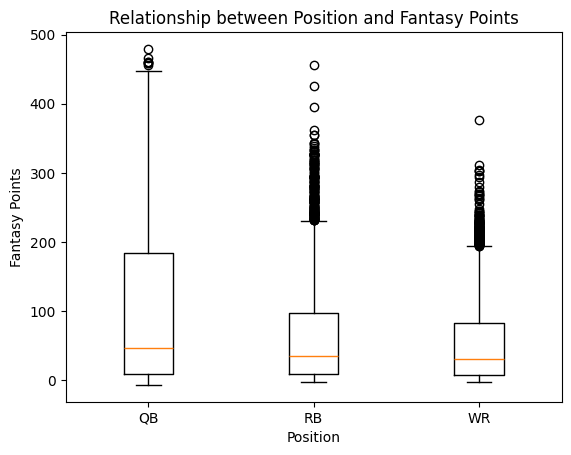

p:value:  2.9317503957734107e-182


In [96]:
#three seperate dataframes are created for players with the positions qb, rb, and wr.
position_group = all_players_cleaned.groupby("position")
qb_df = position_group.get_group("QB")
rb_df = position_group.get_group("RB")
wr_df = position_group.get_group("WR")
#The fantasy points for each df are plotted using a box plot.
fig, ax = plt.subplots()
ax.boxplot((qb_df['fantasy_points'],rb_df['fantasy_points'],wr_df['fantasy_points']),tick_labels =("QB","RB","WR"))
plt.title("Relationship between Position and Fantasy Points")
plt.xlabel("Position")
plt.ylabel("Fantasy Points")
plt.show()
f_statistic, p_value = f_oneway(qb_df['fantasy_points'],rb_df['fantasy_points'],wr_df['fantasy_points'] )
print("p:value: ", p_value)

Conclusion 1: Hypothesis Testing (Anova)

Our first conclusion we have made is that there is a statistically significant difference in fantasy points between the positions QB, RB, and WR with p = 2.93 x 10^-182. Our null hypothesis was that there was no difference in average fantasy points between the positions QB, RB, and WR, and the alternative hypothesis was that ther is a difference in average fantasy points between positions QB, RB, and WR. Since p < 0.05, we reject the null hypothesis. A one-way ANOVA test was used to determine p-value. Based on the plot, QBs appear to score a greater number of fantasy points compared to WRs and RBs.

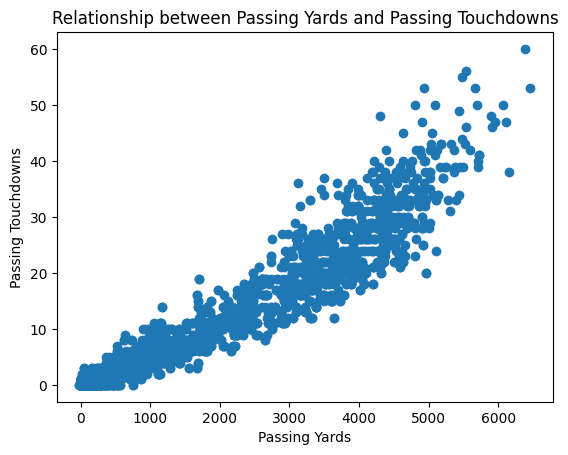

Correlation Coefficient:  0.97297371037095


In [97]:
fig, ax = plt.subplots()
#a scatter plot is created with passing yards on the x axis and passing touchdowns on the y axis.
ax.scatter(all_players_cleaned['passing_yards'], all_players_cleaned['passing_tds'])
plt.title("Relationship between Passing Yards and Passing Touchdowns")
plt.xlabel("Passing Yards")
plt.ylabel("Passing Touchdowns")
plt.show()
corr_coef = np.corrcoef(all_players_cleaned['passing_yards'], all_players_cleaned['passing_tds'])[0,1]
print("Correlation Coefficient: ", corr_coef)

Conclusion 2: Correlation testing (Hypothesis Testing)

A second conclusion we have made based on the above scatter plot is that there is a positive correlation between passing touchdowns and passing yards. The correlation coefficient calculated was 0.973, which is very close to 1 which indicitates a strong positive correlation between passing touchdowns and passing yards.

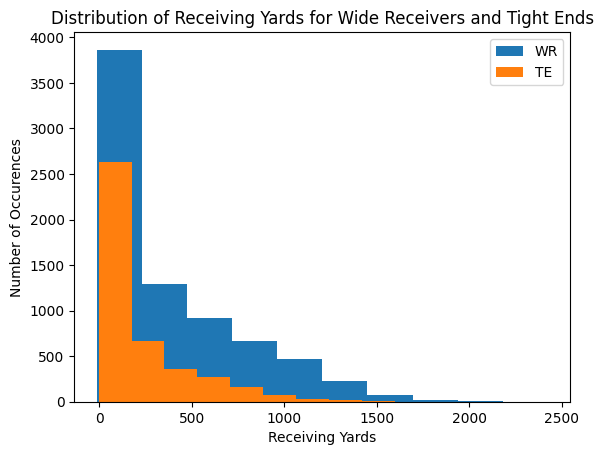

p:value:  9.411838333012043e-115


In [98]:
from scipy.stats import ttest_ind
#players are grouped by position
position_group = all_players_cleaned.groupby("position")
wr_df = position_group.get_group("WR")
te_df = position_group.get_group("TE")

#two histograms are plotted which graph the distribution of receving yards for wide receivers and tight ends.
plt.hist(wr_df['receiving_yards'], label='WR')
plt.hist(te_df['receiving_yards'], label='TE')
plt.xlabel('Receiving Yards')
plt.ylabel('Number of Occurences')
plt.title('Distribution of Receiving Yards for Wide Receivers and Tight Ends')
plt.legend()
plt.show()
x, p_value = ttest_ind(wr_df['receiving_yards'],te_df['receiving_yards'])
print("p:value: ", p_value)

Conclusion 3: Hypothesis Testing (Two-tailed t test)

Another conclusion we have made is that there is a statistically significant difference in receiving yards between the positions WR and TE with p = 9.41 x 10^-115. Our null hypothesis was that there was no difference in average receiving yards between the positions WR and TE, and the alternative hypothesis was that there is a difference in average fantasy points between positions WR and TE. Since p < 0.05, we reject the null hypothesis. A two-tailed t test was used to determine p-value. Based on the plot, WR appear to on average have greater receiving yards compared to TEs.

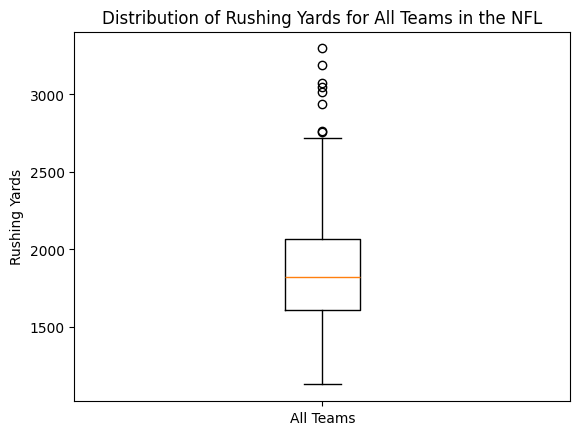

Number of outliers:  8


In [99]:
fig, ax = plt.subplots()

#a box plot is created which graphs rushing yards for all teams in the NFL
ax.boxplot([all_teams_cleaned['rushing_yards']], tick_labels=["All Teams"])
plt.title("Distribution of Rushing Yards for All Teams in the NFL")
plt.ylabel("Rushing Yards")
plt.show()

#number of outliers is calculated
Q1 = all_teams_cleaned['rushing_yards'].quantile(0.25)
Q3 = all_teams_cleaned['rushing_yards'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR
outliers = all_teams_cleaned[(all_teams_cleaned['rushing_yards'] < lower_bound) | (all_teams_cleaned['rushing_yards'] > upper_bound)]
print("Number of outliers: ", len(outliers))

Conclusion 4: Outlier Detection

Another conclusion we have made is that there are 8 outliers for the rushing yards feature. This was determined by identifying teams which had rushing yards greater than 1.5 * IQR + Q3. Based on the boxplot these outliers were all greater than the median. The presence of outliers indicates that a small number of teams have very high rushing yards which may skew our analysis.

## ML Preparation


MVP winners dictionary

In [100]:
# mvp winners by year (1 = MVP)
mvp_winners = {
    "2005" : "Shaun Alexander",
    "2006" : "LaDainian Tomlinson",
    "2007" : "Tom Brady",
    "2008" : "Peyton Manning",
    "2009" : "Peyton Manning",
    "2010" : "Tom Brady",
    "2011" : "Aaron Rodgers",
    "2012" : "Adrian Peterson",
    "2013" : "Peyton Manning",
    "2014" : "Aaron Rodgers",
    "2015" : "Cam Newton",
    "2016" : "Matt Ryan",
    "2017" : "Tom Brady",
    "2018" : "Patrick Mahomes",
    "2019" : "Lamar Jackson",
    "2020" : "Aaron Rodgers",
    "2021" : "Aaron Rodgers"
}

Create is_mvp target (Cleaning Data)

In [101]:
#Filter to only regular season
all_players_cleaned = all_players_cleaned[all_players_cleaned['season_type'] == 'REG'].copy()

#Loop through each player and assign them a 1 if they won that MVP season if not then 0
mvp_list = []
for index, row in all_players_cleaned.iterrows():
    szn = str(row['season'])
    player = row['player_display_name']
    if szn in mvp_winners and mvp_winners[szn] == player:
        mvp_list.append(1)
    else:
        mvp_list.append(0)
all_players_cleaned['is_mvp'] = mvp_list

print(f"Total players: {len(all_players_cleaned)}")
print(f"MVP winners in dataset: {all_players_cleaned['is_mvp'].sum()}")
print(f"\nMVP Players in dataset: ")
display(all_players_cleaned[all_players_cleaned['is_mvp'] == 1][['player_display_name', 'season','position', 'recent_team', 'passing_yards', 'passing_tds','rushing_yards','fantasy_points']])

Total players: 9977
MVP winners in dataset: 17

MVP Players in dataset: 


,player_display_name,season,position,recent_team,passing_yards,passing_tds,rushing_yards,fantasy_points
182,Shaun Alexander,2005,RB,SEA,0,0,1880,361.80
1399,LaDainian Tomlinson,2006,RB,LAC,20,2,1815,425.10
2488,Tom Brady,2007,QB,NE,4806,50,98,390.04
3661,Peyton Manning,2008,QB,IND,4002,27,21,254.18
4887,Peyton Manning,2009,QB,IND,4500,33,-13,278.70
6145,Tom Brady,2010,QB,NE,3900,36,30,299.00
7519,Aaron Rodgers,2011,QB,GB,4636,45,257,397.14
8829,Adrian Peterson,2012,RB,MIN,0,0,2097,307.40
10015,Peyton Manning,2013,QB,DEN,5477,55,-31,409.98
11356,Aaron Rodgers,2014,QB,GB,4381,38,269,354.14


Feature Selection

In [102]:
# select features for the MVP prediction
feature = ['completions', 'attempts', 'passing_yards', 'passing_tds', 'interceptions', 'carries', 'rushing_yards', 'rushing_tds', 'rushing_first_downs', 'receptions', 'targets' , 'receiving_yards', 'receiving_tds', 'games', 'fantasy_points', 'fantasy_points_ppr']

# filter it to only offensive positions
df_model = all_players_cleaned[all_players_cleaned['position'].isin(['QB', 'RB', 'WR', 'TE'])].copy()

# prepares features and target
X = df_model[feature].fillna(0)
Y = df_model['is_mvp']

print(f"feature matrix shape: {X.shape}")
print(f"player position:\n{df_model['position'].value_counts()}")
print(f"\ndistribution: ")
print(f"non-MVP: {(Y == 0).sum()}")
print(f"MVP: {(Y ==1).sum()}")



feature matrix shape: (8876, 16)
player position:
position
WR    3358
RB    2333
TE    1895
QB    1290
Name: count, dtype: int64

distribution: 
non-MVP: 8859
MVP: 17


We created a binary variable called 'is_mvp' which indicates a player won MVP that season with a 1 and 0 if not. Within our dataset, it contains 17 MVP winners from 2005-2021. We filtered to offensive positions and features only because all of the previous MVP winners have been offensive players. The final dataset contained 8,876 offensive players for model training.

## Primary Analysis

Now that we have our objective variable and features ready, we can train a machine learning model to predict NFL MVP winners. We choose a **Random Forest Classifier** because it has built-in feature importance scores, does not require feature scaling, and performs well on highly imbalanced datasets (only 17 MVPs out of 8,876 players).

In [103]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# train/test split
# stratify keeps MVP winners in both splits
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y
)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"MVP winners in training set: {Y_train.sum()}")
print(f"MVP winners in test set: {Y_test.sum()}")

Training set size: 7100
Test set size: 1776
MVP winners in training set: 14
MVP winners in test set: 3


### Train/Test Split

Data is split 80/20 into training and test sets. Despite being very uncommon (only 17 out of 8,876 players), it guarantees that MVP winners appear in both splits. Without stratification, it's possible that all MVP winners will end up in one split by accident.

In [104]:
# train random forest with balanced class weights
model = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
model.fit(X_train, Y_train)

print("successful training.")
print(f"number of trees: {model.n_estimators}")
print(f"features used: {list(X.columns)}")

successful training.
number of trees: 200
features used: ['completions', 'attempts', 'passing_yards', 'passing_tds', 'interceptions', 'carries', 'rushing_yards', 'rushing_tds', 'rushing_first_downs', 'receptions', 'targets', 'receiving_yards', 'receiving_tds', 'games', 'fantasy_points', 'fantasy_points_ppr']


### Model Training

We used 200 decision trees to train a Random Forest. In order to prevent the model from merely predicting non-MVP for every player, the parameter automatically modifies each tree to provide greater weight to the uncommon MVP class.

In [105]:
# evaluate
Y_pred = model.predict(X_test)

print("classification Report:")
print(classification_report(Y_test, Y_pred, target_names=['Not MVP', 'MVP'], zero_division=0))

classification Report:
              precision    recall  f1-score   support

     Not MVP       1.00      1.00      1.00      1773
         MVP       0.00      0.00      0.00         3

    accuracy                           1.00      1776
   macro avg       0.50      0.50      0.50      1776
weighted avg       1.00      1.00      1.00      1776



### Model Evaluation

Overall accuracy is misleading since MVPs are so uncommon so a model that consistently forecasts non-MVPs would be about 99.8% accurate. Instead, we concentrate on recall and precision for the MVP class.

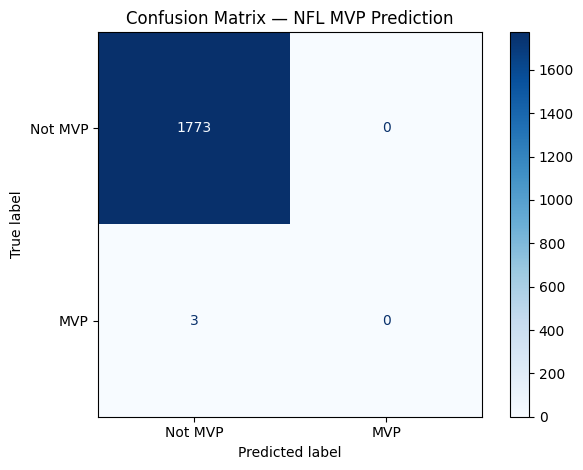

In [106]:
# confusion matrix
cm = confusion_matrix(Y_test, Y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not MVP', 'MVP'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — NFL MVP Prediction')
plt.tight_layout()
plt.show()

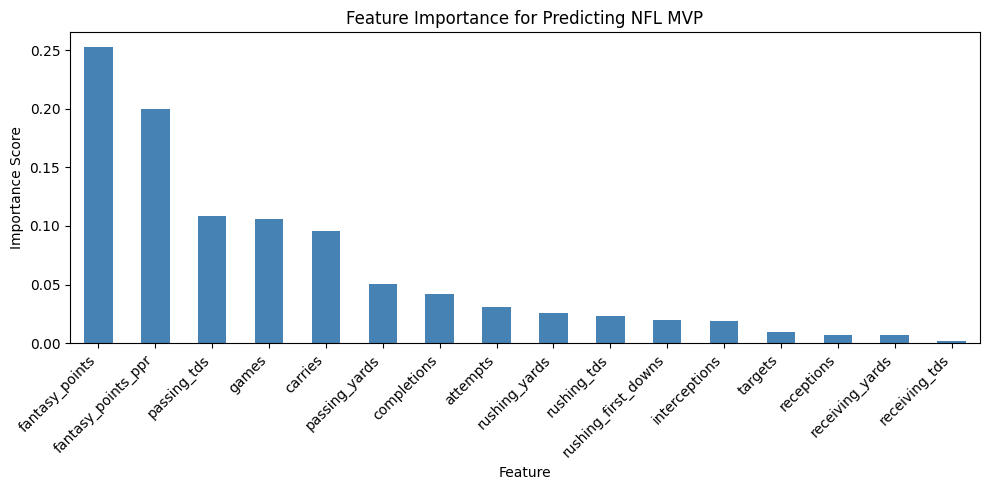

top 5 most important features:
fantasy_points        0.252444
fantasy_points_ppr    0.199547
passing_tds           0.108111
games                 0.105627
carries               0.095664
dtype: float64


In [107]:
# feature importance plot
feature_names = list(X.columns)
importances = model.feature_importances_
importance_series = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
importance_series.plot(kind='bar', color='steelblue')
plt.title('Feature Importance for Predicting NFL MVP')
plt.xlabel('Feature')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("top 5 most important features:")
print(importance_series.head())

### Feature Importance

The model's most highly weighted statistics for MVP prediction are displayed in the feature importance plot. Because the majority of MVP winners in this dataset are high-volume quarterbacks, fantasy points and passing statistics typically dominate.

In [108]:
# MVP probability ranking for the most recent season
df_2021 = df_model[df_model['season'] == 2021].copy()
X_2021 = df_2021[feature].fillna(0)

df_2021['mvp_prob'] = model.predict_proba(X_2021)[:, 1]

top_candidates = (df_2021
    .sort_values('mvp_prob', ascending=False)
    [['player_display_name', 'position', 'recent_team', 'mvp_prob'] + feature]
    .head(10)
    .reset_index(drop=True)
)

print("Top 10 Predicted MVP Candidates for 2021:")
display(top_candidates[['player_display_name', 'position', 'recent_team', 'mvp_prob']])

Top 10 Predicted MVP Candidates for 2021:


,player_display_name,position,recent_team,mvp_prob
0,Kirk Cousins,QB,MIN,0.350
1,Aaron Rodgers,QB,GB,0.225
2,Jonathan Taylor,RB,IND,0.185
3,Dak Prescott,QB,DAL,0.165
4,Joe Burrow,QB,CIN,0.075
5,Tom Brady,QB,TB,0.065
6,Josh Allen,QB,BUF,0.040
7,Patrick Mahomes,QB,KC,0.020
8,Carson Wentz,QB,IND,0.010
9,Matthew Stafford,QB,LA,0.010


##Visualization

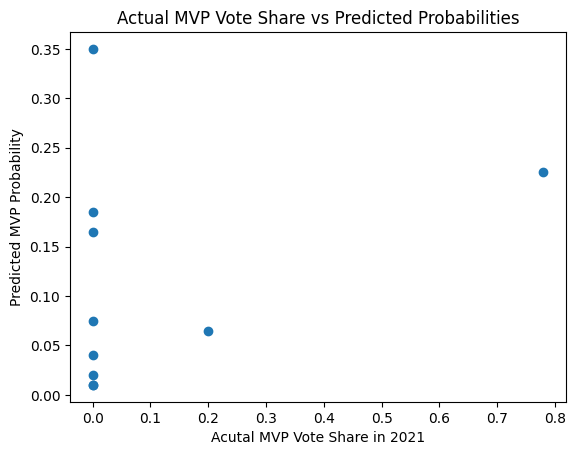

In [109]:
# a column is created with the actual MVP vote share each predicted player received in 2021
top_candidates['vote_share'] = [0,0.78,0,0,0,0.20,0,0,0,0]

#a scatter plot is created which graphs the actual MVP vote share in 2021 vs our model's predicted probability
plt.figure()
plt.scatter(top_candidates['vote_share'], top_candidates['mvp_prob'])
plt.xlabel("Acutal MVP Vote Share in 2021")
plt.ylabel("Predicted MVP Probability")
plt.title("Actual MVP Vote Share vs Predicted Probabilities")
plt.show()



Based on our visualization our model tends to assign high MVP probabilities to players who received no MVP votes, which are false positives. This is likely caused by the huge class imbalance in our dataset since a very small fraction of players receive MVP votes. However, our model was able to classify players who received MVP votes as likely MVP candidates.  